In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("E0.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(380, 106)
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA']


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


In [4]:
df.loc[:, ["HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "PSH", "PSD", "PSA"]].head(20)

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,PSH,PSD,PSA
0,Burnley,Man City,0,3,A,8.58,5.51,1.37
1,Arsenal,Nott'm Forest,2,1,H,1.18,7.86,15.67
2,Bournemouth,West Ham,1,1,D,2.70,3.47,2.71
3,Brighton,Luton,4,1,H,1.33,5.65,9.61
4,Everton,Fulham,0,1,A,2.27,3.45,3.35
5,Sheffield United,Crystal Palace,0,1,A,3.28,3.22,2.43
6,Newcastle,Aston Villa,5,1,H,1.77,3.92,4.77
7,Brentford,Tottenham,2,2,D,2.76,3.65,2.55
8,Chelsea,Liverpool,1,1,D,2.97,3.64,2.40
9,Man United,Wolves,1,0,H,1.32,5.79,9.66


In [5]:
total_probability_margin = []
for i in range(20):
    home_team = df.loc[i, "PSH"]
    away_team = df.loc[i, "PSA"]
    draw = df.loc[i, "PSD"]
    ith_game_margin = ((1/home_team) + (1/away_team) + (1/draw)) - 1
    total_probability_margin.append(ith_game_margin)
print(total_probability_margin)

[np.float64(0.027965327116174388), np.float64(0.03850029954013645), np.float64(0.027558498447616486), np.float64(0.032929122323272386), np.float64(0.02889116951156878), np.float64(0.026959688736523768), np.float64(0.029717398098776826), np.float64(0.02844830606453419), np.float64(0.0280922780922781), np.float64(0.033806997988119925), np.float64(0.023803486982129973), np.float64(0.02839586529007576), np.float64(0.040324187394278344), np.float64(0.02973538103528961), np.float64(0.027595057030597614), np.float64(0.03027045443864851), np.float64(0.029650373751273218), np.float64(0.028041651443186044), np.float64(0.030735448925307107), np.float64(0.027337412242793624)]


In [6]:
profit_part = (1/df.PSH + 1/df.PSA + 1/df.PSD)
print(profit_part)

0      1.027965
1      1.038500
2      1.027558
3      1.032929
4      1.028891
         ...   
375    1.042661
376    1.043690
377    1.038877
378    1.042752
379    1.047072
Length: 380, dtype: float64


In [7]:
idh = df.columns.get_loc("PSH")
idd = df.columns.get_loc("PSD")
ida = df.columns.get_loc("PSA")
print(idh, idd, ida)

33 34 35


In [8]:
df.PSH / profit_part
df.PSA / profit_part
df.PSD / profit_part
adjusted_odds = pd.DataFrame({'PSH_adj': df.PSH * profit_part, 'PSD_adj': df.PSD * profit_part, 'PSA_adj': df.PSA * profit_part})
df_2 = df.copy()
df_2 = pd.concat([df_2.iloc[:, :ida +1], adjusted_odds, df_2.iloc[:, ida + 1:]], axis=1)

print(df_2.loc[:, ["PSH", "PSD", "PSA", "PSH_adj", "PSD_adj", "PSA_adj"]].head(20))



     PSH   PSD    PSA   PSH_adj   PSD_adj    PSA_adj
0   8.58  5.51   1.37  8.819943  5.664089   1.408312
1   1.18  7.86  15.67  1.225430  8.162612  16.273300
2   2.70  3.47   2.71  2.774408  3.565628   2.784684
3   1.33  5.65   9.61  1.373796  5.836050   9.926449
4   2.27  3.45   3.35  2.335583  3.549675   3.446785
5   3.28  3.22   2.43  3.368428  3.306810   2.495512
6   1.77  3.92   4.77  1.822600  4.036492   4.911752
7   2.76  3.65   2.55  2.838517  3.753836   2.622543
8   2.97  3.64   2.40  3.053434  3.742256   2.467421
9   1.32  5.79   9.66  1.364625  5.985743   9.986576
10  1.97  3.48   4.37  2.016893  3.562836   4.474021
11  2.76  3.43   2.67  2.838373  3.527398   2.745817
12  1.23  7.14  11.46  1.279599  7.427915  11.922115
13  4.12  3.92   1.88  4.242510  4.036563   1.935903
14  2.85  3.82   2.41  2.928646  3.925413   2.476504
15  1.73  4.10   4.80  1.782368  4.224109   4.945298
16  1.72  3.99   5.06  1.770999  4.108305   5.210031
17  3.68  3.57   2.10  3.783193  3.670109   2.

In [9]:
df_2["PSH_prob"] = 1 / df_2["PSH_adj"]
df_2["PSD_prob"] = 1 / df_2["PSD_adj"]
df_2["PSA_prob"] = 1 / df_2["PSA_adj"]
df_2["binsH"]= pd.cut(df_2["PSH_prob"], bins=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], right=False)
df_2["binsD"]= pd.cut(df_2["PSD_prob"], bins=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], right=False)
df_2["binsA"]= pd.cut(df_2["PSA_prob"], bins=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], right=False)
df_2["binsH"].value_counts().sort_index()
print(df_2["binsH"])

0      [0.1, 0.2)
1      [0.8, 0.9)
2      [0.3, 0.4)
3      [0.7, 0.8)
4      [0.4, 0.5)
          ...    
375    [0.5, 0.6)
376    [0.8, 0.9)
377    [0.3, 0.4)
378    [0.8, 0.9)
379    [0.1, 0.2)
Name: binsH, Length: 380, dtype: category
Categories (9, interval[float64, left]): [[0.1, 0.2) < [0.2, 0.3) < [0.3, 0.4) < [0.4, 0.5) ... [0.6, 0.7) < [0.7, 0.8) < [0.8, 0.9) < [0.9, 1.0)]


In [10]:
# trackig the actual wins (just for home teams here)

df_2["home_win"] = (df_2["FTR"] == "H").astype(int)
df_2["away_win"] = (df_2["FTR"] == "A").astype(int)
df_2["draw"] = (df_2["FTR"] == "D").astype(int)

df_2[["FTR", "home_win", "away_win", "draw"]].head(20)

,FTR,home_win,away_win,draw
0,A,0,1,0
1,H,1,0,0
2,D,0,0,1
3,H,1,0,0
4,A,0,1,0
5,A,0,1,0
6,H,1,0,0
7,D,0,0,1
8,D,0,0,1
9,H,1,0,0


/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_2053/3523203030.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yH =  df_2.groupby("binsH")["home_win"].mean().sort_index() # Expectation of indicator functions are literlly probabilities
/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_2053/3523203030.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yA =  df_2.groupby("binsA")["away_win"].mean().sort_index()
/var/folders/5w/3d7_1yz55cd3w_l664lgmqdw0000gn/T/ipykernel_2053/3523203030.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futur

Text(0.5, 1.0, 'Calibration Plot for Home Win Predictions')

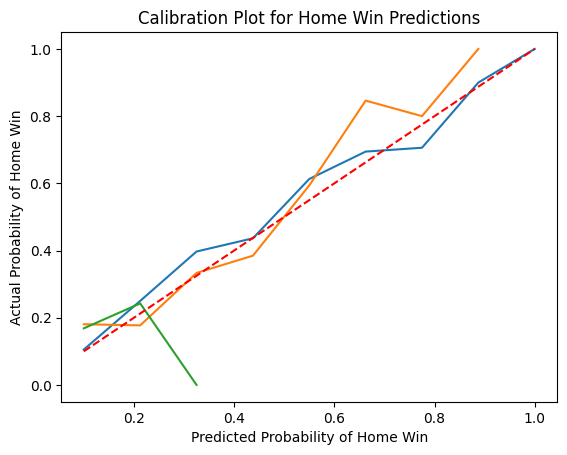

In [11]:
yH =  df_2.groupby("binsH")["home_win"].mean().sort_index() # Expectation of indicator functions are literlly probabilities 
yA =  df_2.groupby("binsA")["away_win"].mean().sort_index()
yD =  df_2.groupby("binsD")["draw"].mean().sort_index()


x = np.linspace(0.1, 1.0, 9)
plt.plot(x, yH)
plt.plot(x, yA)
plt.plot(x, yD)
plt.plot(x, x, color='red', linestyle='--')
plt.xlabel("Predicted Probability of Home Win")
plt.ylabel("Actual Probability of Home Win")
plt.title("Calibration Plot for Home Win Predictions")

In [12]:
#Now calculating ROI 
df_2["ROI_H"] = np.where(df_2["home_win"]== 1, df_2["PSH"]-1, -1)
df_2["ROI_A"] = np.where(df_2["away_win"]== 1, df_2["PSA"]-1, -1)
df_2["ROI_D"] = np.where(df_2["draw"]== 1, df_2["PSD"]-1, -1)

print(df_2["ROI_H"].mean())
print(df_2["ROI_A"].mean())
print(df_2["ROI_D"].mean())

# Sanity checking bc this seems way too big for ROI
# print(df_2["home_win"].sum() + df_2["away_win"].sum() + df_2["draw"].sum())
# print(df_2[["PSH", "PSD", "PSA", "home_win", "away_win", "draw"]].isnull().sum())
# print(df_2["home_win"].mean())
# print(1 / df_2["PSH"].mean())
# print(df_2["FTR"].value_counts())
# print(df_2["PSH"].mean())
# print(df_2["ROI_H"].value_counts())

-0.04526315789473684
-0.1173421052631579
-0.08857894736842105
